In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib.inline
import warnings
warnings.filterwarning('ignore')

UsageError: Line magic function `%matplotlib.inline` not found.


In [36]:
df = pd.read_csv('data\stud.csv')

In [37]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [38]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']

In [39]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
 8   total_score                  1000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [41]:
df.shape

(1000, 9)

In [42]:
df['parental_level_of_education'].value_counts()

parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [43]:
df['test_preparation_course'].value_counts()

test_preparation_course
none         642
completed    358
Name: count, dtype: int64

In [44]:
df['race_ethnicity'].value_counts()

race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

<Axes: xlabel='gender', ylabel='total_score'>

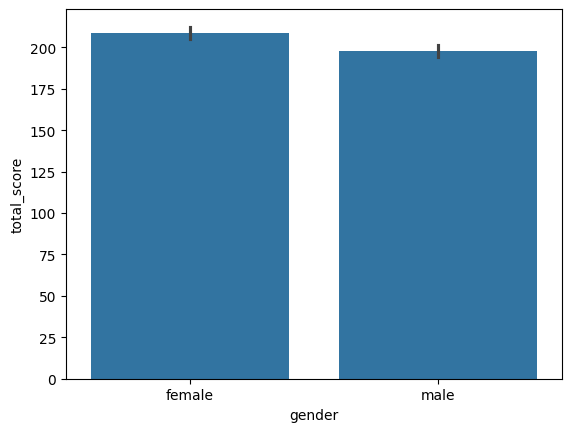

In [45]:
sns.barplot(x='gender', y='total_score', data=df)

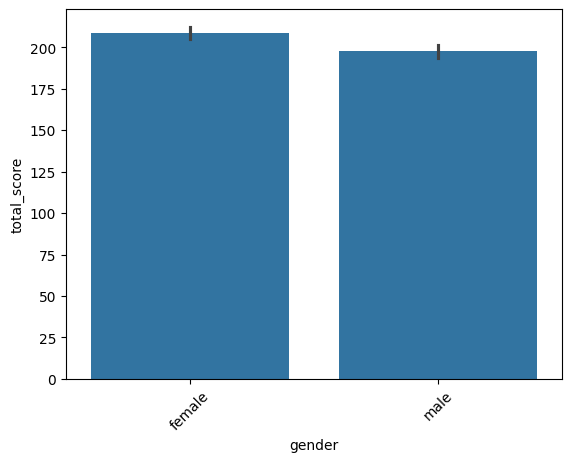

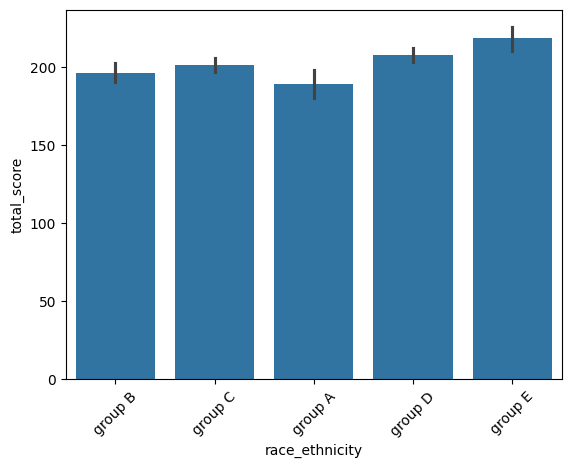

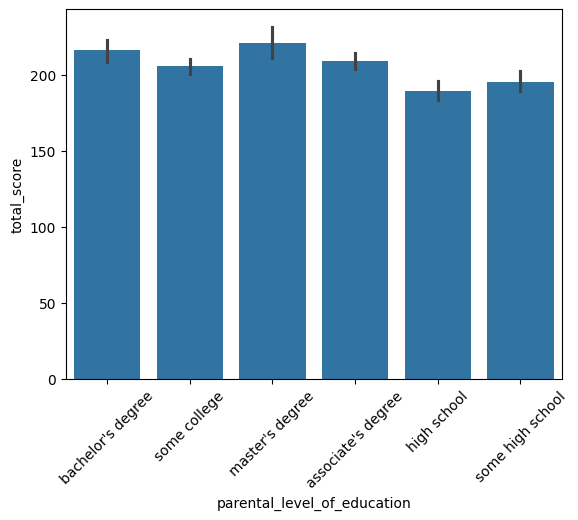

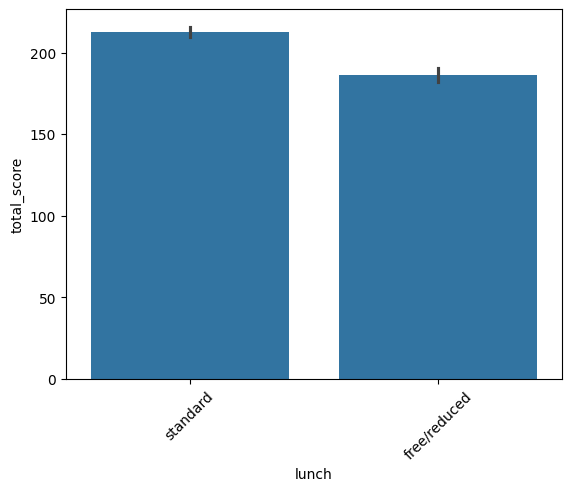

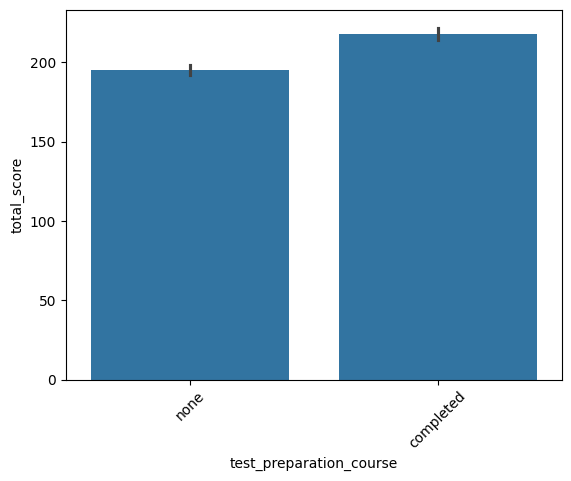

In [46]:
for i in df.columns:
    if df[i].dtype == 'object':
        sns.barplot(x=i, y='total_score', data=df)
        plt.xticks(rotation=45)
        plt.show()

In [47]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
total_score                    0
dtype: int64

In [48]:
col_names = list(df.columns)
col_names

['gender',
 'race_ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course',
 'math_score',
 'reading_score',
 'writing_score',
 'total_score']

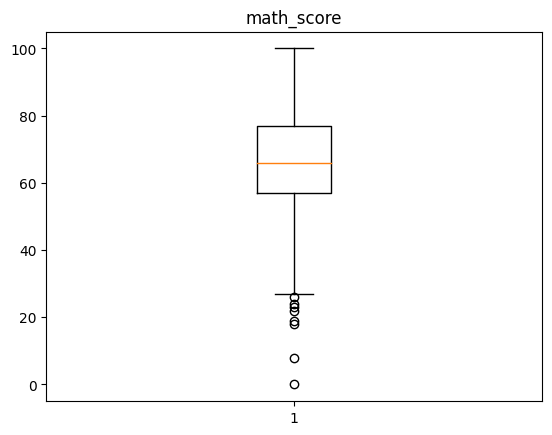

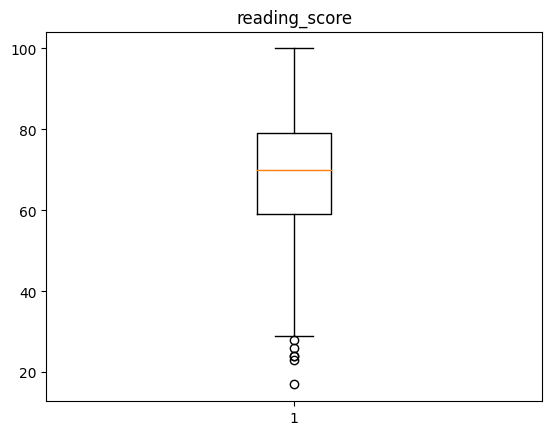

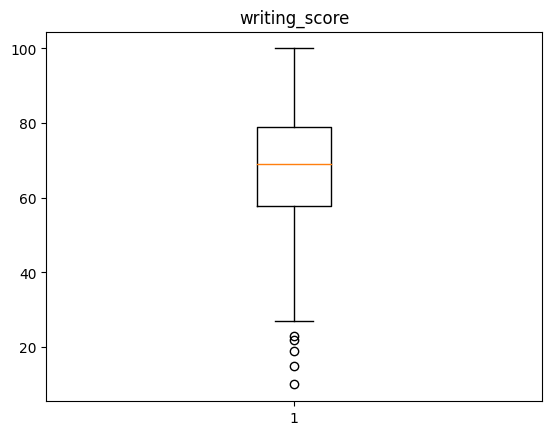

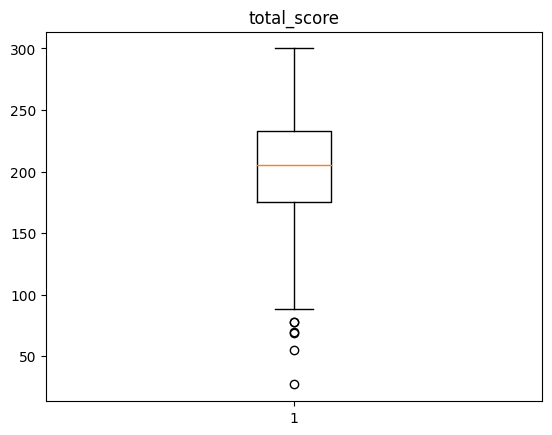

In [49]:
for i in df.columns:
    if df[i].dtype != 'object':
        plt.boxplot(x=df[i])
        plt.title(i)
        plt.show()

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
 8   total_score                  1000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [51]:
col_names = ['math_score', 'reading_score', 'writing_score', 'total_score']

In [52]:
for i in col_names:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1
    lw = q1 - 1.5 * iqr
    uw = q3 + 1.5 * iqr
    df = df.loc[(df[i] > lw) & (df[i] < uw)].copy()

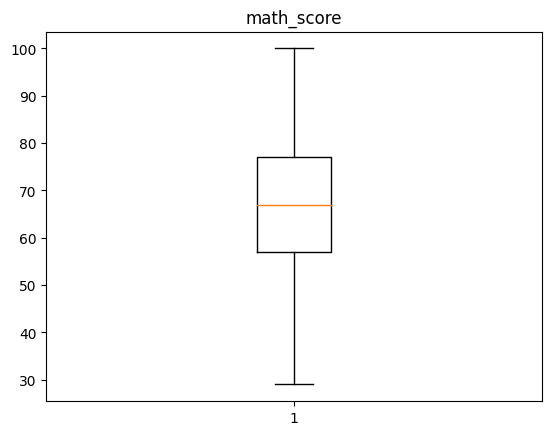

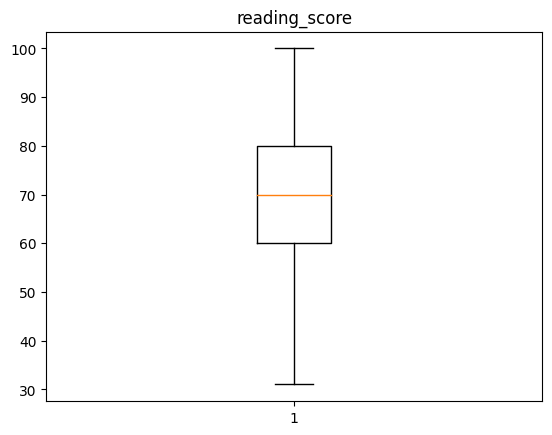

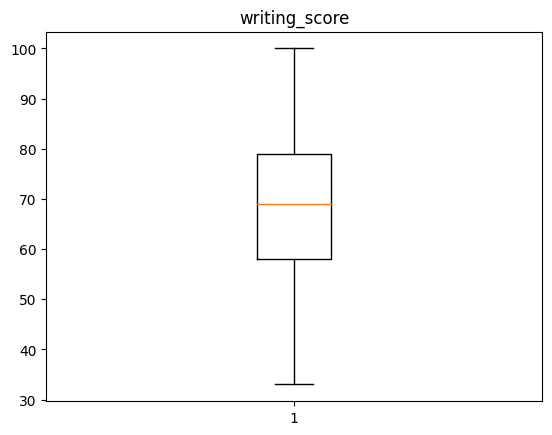

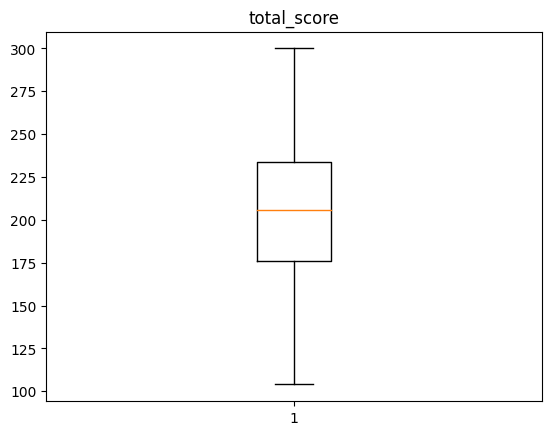

In [53]:
for i in df.columns:
    if df[i].dtype != 'object':
        plt.boxplot(x=df[i])
        plt.title(i)
        plt.show()

In [55]:
df.shape

(984, 9)

#Maximumum score of students in all three subjects

In [60]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


Text(0.5, 1.0, 'Writing Score')

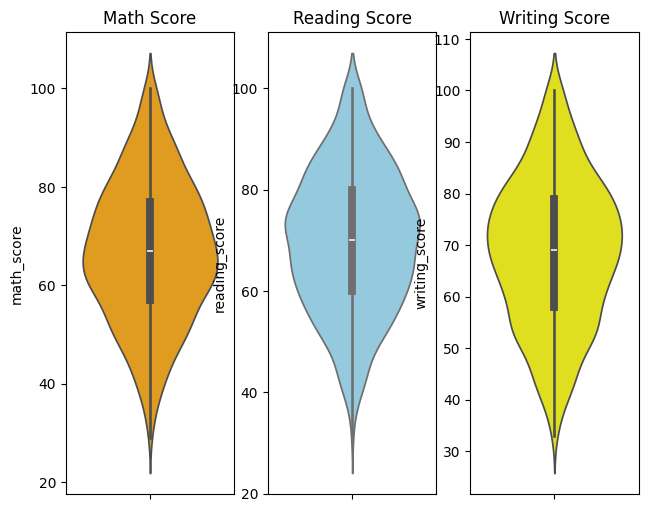

In [62]:
plt.figure(figsize=(10, 6))

plt.subplot(1,4,1)
sns.violinplot(y='math_score', data=df, color='orange')
plt.title('Math Score')

plt.subplot(1,4,2)
sns.violinplot(y='reading_score', data=df, color='skyblue')
plt.title('Reading Score')

plt.subplot(1,4,3)
sns.violinplot(y='writing_score', data=df, color='yellow')
plt.title('Writing Score')

we can find that student scores in math and writing scores between 50 to 80 while in writing the maximum student scores between 50 to 80 